In [1]:
using Pkg
Pkg.activate(joinpath(@__DIR__, "..","DTENV"))
Pkg.instantiate()
if size(LOAD_PATH,1) < 4
    push!(LOAD_PATH, joinpath(@__DIR__,"..","scripts"))
end

  Activating project at `c:\Users\Ivan\Desktop\Stuff4School\Thesis\CleanDTFE\DTENV`


4-element Vector{String}:
 "@"
 "@v#.#"
 "@stdlib"
 "c:\\Users\\Ivan\\Desktop\\Stuff4School\\Thesis\\CleanDTFE\\notebooks\\..\\scripts"

In [2]:
using TetGen
using StaticArrays
using JLD
using BenchmarkTools
using LinearAlgebra
using Plots

In [3]:
include("../scripts/TesselationCore.jl")
import .TesselationCore

BVH = TesselationCore.BVH
point3 = TesselationCore.point3

SVector{3, Float64} (alias for SArray{Tuple{3}, Float64, 1, 3})

In [4]:
import illustris_julia as il


basePath = "../../DTFE/Illustris3/output";

fields = ["SubhaloMass","SubhaloCM"];
subhalos = il.groupcat.loadSubhalos(basePath,135,fields)

positions = subhalos["SubhaloCM"]


3×121209 Matrix{Float32}:
   877.298    178.518    824.483  …  56394.3   64350.5  64728.4  61624.0
 26328.5    24557.1    26747.8        2440.16  31243.2  72960.7  66575.4
 18063.6    16858.7    17363.8       15078.2   39500.2  53679.3  32452.4

In [5]:
function standardEstimator(points, weights, depth = 9)

    coords, tets = TesselationCore.tesselate(points)
    tes = TesselationCore.Triangulation3D(points,tets',weights)

    simplices = coords[:,tets]
    bvh = BVH(simplices,depth)

    return bvh,tes,tets
end


function standardEstimator(points,depth = 9)

    coords, tets = TesselationCore.tesselate(points)
    tes = TesselationCore.Triangulation3D(points,tets')

    simplices = coords[:,tets]
    bvh = BVH(simplices,depth)

    return bvh,tes,tets
end



standardEstimator (generic function with 3 methods)

In [6]:
function DTFE(point,bvh,tetrahedra,tesselation)

    coords = tesselation.points
    simplices = coords[tetrahedra]

    i = TesselationCore.findID(point,simplices,bvh)
    if i == nothing
        return 0
    end

    tet = tetrahedra[i,:]
    simp = coords[tet]
    rhos = tesselation.ρStar[tet]

    delRho=invertClassic(rhos,simp)

    interpolation = rhos[1] + dot((point - simp[1]),delRho)

    return interpolation
end

function invertClassic(rhos,simplex) 
    r = rhos[2:end] .- rhos[1]

    v1, v2, v3, v4 = simplex[1], simplex[2], simplex[3], simplex[4]

    a = v2 - v1 
    b = v3 - v1 
    c = v4 - v1

    mat = SMatrix{3,3}([a;b;c])
    
    return inv(mat)*r
end



invertClassic (generic function with 1 method)

In [7]:
gap = 50
points = positions[:,1:gap:end]
ps = [point3(points[1,i], points[2,i], points[3,i]) for i in 1:size(points,2)]

bvh,tes,tets = standardEstimator(ps,10)
print("done")

done

In [8]:
N = 1000

width = 75000

step = width/N


xs = bvh.bbox[1,1]:step:bvh.bbox[1,2]
ys = bvh.bbox[2,1]:step:bvh.bbox[2,2]

z = (bvh.bbox[3,2] + bvh.bbox[3,1])/2

dens = zeros(N,N)
print("Done")

Done

In [9]:
for (i,x) in pairs(xs)
    for (j,y) in pairs(ys)
        dens[i,j] = DTFE([x,y,z],bvh,tets,tes)

    end
end

In [10]:
med = median(dens)

3.971531645249177e-12

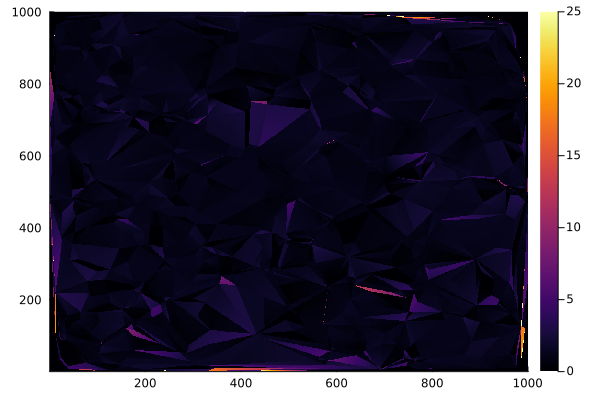

In [11]:
Plots.heatmap(dens ./med,clim=(0,25))

In [12]:
N = 100

width = 75000

step = width/N


xs = bvh.bbox[1,1]:step:bvh.bbox[1,2]
ys = bvh.bbox[2,1]:step:bvh.bbox[2,2]

zs =  bvh.bbox[3,1]:step:bvh.bbox[3,2]

dens = zeros(N,N,N)
print("Done")

Done

In [13]:
DTFE([35000.,35000.,35000.],bvh,tets,tes)

2.1390745266731447e-12

In [14]:
for (i,x) in pairs(xs)
    for (j,y) in pairs(ys)
        for (k,z) in pairs(zs)
            dens[i,j,k] = DTFE([x,y,z],bvh,tets,tes)

        end

    end
end

In [15]:
using ColorSchemes
using GLMakie
lowColor  = get(ColorSchemes.acton,LinRange(0,1,256))[1]

fig = GLMakie.Figure(size = (1600,1600),backgroundcolor=lowColor)
ax = GLMakie.LScene(fig[1,1],scenekw=(show_axis=false,backgroundcolor=lowColor))
volplot = volume!(
    ax,dens ./median(dens),
    algorithm=:mip,
    colormap = :acton,
    colorrange = (.0,25),
    )

Volume{Tuple{Makie.EndPoints{Float32}, Makie.EndPoints{Float32}, Makie.EndPoints{Float32}, Array{Float32, 3}}}

In [16]:
fig

In [19]:
save("../Images/DTFE.png", fig)  